Importamos las librerías

In [ ]:
import pandas as pd
import numpy as np

Cargamos el dataset del proyecto

In [ ]:
df = pd.read_excel('db_pmbok_project_.xlsx', header=0)
df.columns

Index(['nombre_proyecto', 'tipo_proyecto', 'id_proyecto', 'fecha_proyecto',
       'area', 'grupo', 'recurso_tiempo', 'recurso_costo', 'recurso_varios',
       'resultado', 'descripcion_actividad', 'leccion_aprendida', 'indicador'],
      dtype='object')

Identificamos los valores NA

In [ ]:
df['indicador'].isna().sum()

np.int64(2)

Eliminamos los valores NA

In [ ]:
df = df.dropna(subset=['indicador'])
df['indicador'].isna().sum()

np.int64(0)

Modificamos a solo 3 grupos

In [ ]:
mapa_grupos = {
    1: 1,
    2: 1,
    3: 2,
    4: 2,
    5: 3,
    6: 3,
    7: 3
}

df['grupo'] = df['grupo'].map(mapa_grupos)
df.head()

,nombre_proyecto,tipo_proyecto,id_proyecto,fecha_proyecto,area,grupo,recurso_tiempo,recurso_costo,recurso_varios,resultado,descripcion_actividad,leccion_aprendida,indicador
0,API One,Desarrollo de software,1,2020,4,1,1,136000.0,5,exito,Se desarrolla el acta de constitución del proy...,El tiempo destinado para el desarrollo del act...,"Los recursos en base a tiempo, costo y número ..."
1,API One,Desarrollo de software,1,2020,4,1,1,136000.0,7,exito,Se desarrolla el plan para la dirección del pr...,El presupuesto de costo destinado al desarroll...,"Los recursos en base a tiempo, costo y número ..."
2,API One,Desarrollo de software,1,2020,4,2,155,136000.0,7,exito,Se dirige y gestiona el trabajo del proyecto,El recurso humano destinado para esta activida...,"Los recursos en base a tiempo, costo y número ..."
3,API One,Desarrollo de software,1,2020,4,2,1,136000.0,3,exito,Se gestiona el conocimiento del proyecto,El tiempo destinado para gestionar el conocimi...,"Los recursos en base a tiempo, costo y número ..."
4,API One,Desarrollo de software,1,2020,4,3,155,136000.0,4,exito,Se monitorea y controla el Trabajo del Proyecto,El presupuesto de costo destinado al monitoreo...,"Los recursos en base a tiempo, costo y número ..."


Aplicamos la representación para la columna indicador y el one hot encoding a la columna grupo

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import OneHotEncoder

# =========================
# Definición de columnas
# =========================
text_col = "indicador"
num_cols = ["recurso_tiempo", "recurso_costo", "recurso_varios", "resultado"]
cat_cols = ["grupo"]

# =========================
# Pipeline de texto: TF-IDF + SVD (5)
# =========================
text_pipe = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_features=1500
    )),
    ("svd", TruncatedSVD(n_components=4, random_state=42))
])

# =========================
# ColumnTransformer
# =========================
preprocess = ColumnTransformer(
    transformers=[
        ("txt", text_pipe, text_col),
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(
            sparse_output=False,
            handle_unknown="ignore"
        ), cat_cols)
    ],
    remainder="drop",
    sparse_threshold=0.0
)

# =========================
# Transformación del dataset
# =========================
X_out = preprocess.fit_transform(df)

# =========================
# Construcción de nombres de columnas
# =========================
# Texto (SVD)
text_features = [f"indicador_svd_{i+1:02d}" for i in range(4)]

# Numéricas
num_features = num_cols

# One-hot de 'grupo'
cat_features = preprocess.named_transformers_["cat"] \
    .get_feature_names_out(cat_cols)

# Lista final de columnas
feature_names = text_features + num_features + list(cat_features)

# =========================
# DataFrame final
# =========================
df_def = pd.DataFrame(
    X_out,
    columns=feature_names,
    index=df.index
)

df_def.head()

,indicador_svd_01,indicador_svd_02,indicador_svd_03,indicador_svd_04,recurso_tiempo,recurso_costo,recurso_varios,resultado,grupo_1,grupo_2,grupo_3
0,0.998234,-0.057316,-0.005837,0.014401,1,136000.0,5,exito,1.0,0.0,0.0
1,0.998234,-0.057316,-0.005837,0.014401,1,136000.0,7,exito,1.0,0.0,0.0
2,0.998234,-0.057316,-0.005837,0.014401,155,136000.0,7,exito,0.0,1.0,0.0
3,0.998234,-0.057316,-0.005837,0.014401,1,136000.0,3,exito,0.0,1.0,0.0
4,0.998234,-0.057316,-0.005837,0.014401,155,136000.0,4,exito,0.0,0.0,1.0


Realizamos el mapeo de las columnas categóricas

In [ ]:
mapa = {'fracaso': 0, 'exito': 1}   #recomendado para binario
df_def['res_num'] = df_def['resultado'].str.lower().map(mapa)
df_def

,indicador_svd_01,indicador_svd_02,indicador_svd_03,indicador_svd_04,recurso_tiempo,recurso_costo,recurso_varios,resultado,grupo_1,grupo_2,grupo_3,res_num
0,0.998234,-0.057316,-0.005837,0.014401,1,136000.0,5,exito,1.0,0.0,0.0,1
1,0.998234,-0.057316,-0.005837,0.014401,1,136000.0,7,exito,1.0,0.0,0.0,1
2,0.998234,-0.057316,-0.005837,0.014401,155,136000.0,7,exito,0.0,1.0,0.0,1
3,0.998234,-0.057316,-0.005837,0.014401,1,136000.0,3,exito,0.0,1.0,0.0,1
4,0.998234,-0.057316,-0.005837,0.014401,155,136000.0,4,exito,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
180,0.998234,-0.057316,-0.005837,0.014401,3,1600000.0,2,exito,0.0,1.0,0.0,1
181,0.000922,0.000611,0.001094,-0.001089,15,1000000.0,10,fracaso,0.0,1.0,0.0,0
182,0.154507,0.100523,0.092747,-0.067976,10,1000000.0,1,exito,1.0,0.0,0.0,1
183,0.042416,0.027607,0.025982,-0.019319,30,10000000.0,5,exito,1.0,0.0,0.0,1


Eliminamos la variable resultado

In [ ]:
df_def = df_def.drop(columns=['resultado'])
df_def.head()

,indicador_svd_01,indicador_svd_02,indicador_svd_03,indicador_svd_04,recurso_tiempo,recurso_costo,recurso_varios,grupo_1,grupo_2,grupo_3,res_num
0,0.998234,-0.057316,-0.005837,0.014401,1,136000.0,5,1.0,0.0,0.0,1
1,0.998234,-0.057316,-0.005837,0.014401,1,136000.0,7,1.0,0.0,0.0,1
2,0.998234,-0.057316,-0.005837,0.014401,155,136000.0,7,0.0,1.0,0.0,1
3,0.998234,-0.057316,-0.005837,0.014401,1,136000.0,3,0.0,1.0,0.0,1
4,0.998234,-0.057316,-0.005837,0.014401,155,136000.0,4,0.0,0.0,1.0,1


Contamos ahora la cantidad de ceros y unos

In [10]:
df_def['res_num'].value_counts()

,count
res_num,
1,102
0,81


Aplicamos ahora one hot encoding paras las variables que son categóricas

In [11]:
y = df_def['res_num']
X = df_def.drop(columns=['res_num'])
X

,indicador_svd_01,indicador_svd_02,indicador_svd_03,indicador_svd_04,recurso_tiempo,recurso_costo,recurso_varios,grupo_1,grupo_2,grupo_3
0,0.998234,-0.057316,-0.005837,0.014401,1,136000.0,5,1.0,0.0,0.0
1,0.998234,-0.057316,-0.005837,0.014401,1,136000.0,7,1.0,0.0,0.0
2,0.998234,-0.057316,-0.005837,0.014401,155,136000.0,7,0.0,1.0,0.0
3,0.998234,-0.057316,-0.005837,0.014401,1,136000.0,3,0.0,1.0,0.0
4,0.998234,-0.057316,-0.005837,0.014401,155,136000.0,4,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
180,0.998234,-0.057316,-0.005837,0.014401,3,1600000.0,2,0.0,1.0,0.0
181,0.000922,0.000611,0.001094,-0.001089,15,1000000.0,10,0.0,1.0,0.0
182,0.154507,0.100523,0.092747,-0.067976,10,1000000.0,1,1.0,0.0,0.0
183,0.042416,0.027607,0.025982,-0.019319,30,10000000.0,5,1.0,0.0,0.0


# Red neuronal

Fijamos la semilla para hacer el experimento replicable

In [12]:
# 1) SEMILLA (primera línea lógica del script)
import os, random, numpy as np, tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

Dividimos los datos en conjunto de entrenamiento y prueba

In [13]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
x_train

,indicador_svd_01,indicador_svd_02,indicador_svd_03,indicador_svd_04,recurso_tiempo,recurso_costo,recurso_varios,grupo_1,grupo_2,grupo_3
57,0.119154,0.648237,-0.71631,-0.097425,1,424359.16,2,0.0,1.0,0.0
103,0.156139,0.635603,0.557086,-0.171283,10,195000.0,10,1.0,0.0,0.0
92,0.156139,0.635603,0.557086,-0.171283,5,400000.0,4,0.0,1.0,0.0
138,0.998234,-0.057316,-0.005837,0.014401,6,2400000.0,3,0.0,0.0,1.0
45,0.998234,-0.057316,-0.005837,0.014401,2,73000.0,6,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
46,0.998234,-0.057316,-0.005837,0.014401,2,73000.0,6,1.0,0.0,0.0
2,0.998234,-0.057316,-0.005837,0.014401,155,136000.0,7,0.0,1.0,0.0
97,0.156139,0.635603,0.557086,-0.171283,1,122000.0,2,1.0,0.0,0.0
86,0.156139,0.635603,0.557086,-0.171283,9,136000.0,3,0.0,1.0,0.0


Procedemos con el escalado de los datos que no son one hot encoding

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Ajustar SOLO con entrenamiento
x_train_scal = scaler.fit_transform(x_train)
# Aplicar la misma transformación a test
x_test_scal = scaler.transform(x_test)

Procedemos con la red neuornal

In [15]:
import tensorflow as tf
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.optimizers import Adam

class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1', threshold=0.6, **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = Precision(thresholds=threshold)
        self.recall = Recall(thresholds=threshold)

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

Definimos la arquitectura del modelo

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC

# Arquitectura más compacta y regularizada
model = Sequential()
model.add(Dense(units=12,activation='relu',input_shape=(10,),kernel_regularizer=regularizers.l2(1e-4)))
model.add(Dropout(0.3))
model.add(Dense(units=8,activation='relu',kernel_regularizer=regularizers.l2(1e-4)))
model.add(Dropout(0.3))
model.add(Dense(units=4,activation='relu',kernel_regularizer=regularizers.l2(1e-4)))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=[
        'accuracy',
        Precision(name='precision',thresholds=0.5),
        Recall(name='recall',thresholds=0.5),
        F1Score(name='f1', threshold=0.5),
        AUC(name='auc')
    ])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277 (1.08 KB)

 Trainable params: 277 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Callbacks para optimizar el entrenamiento
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

Limpiamos la memoria

In [18]:
import tensorflow as tf
from tensorflow.keras.backend import clear_session

# Limpiar el estado del modelo en la memoria de la GPU
clear_session()

Ajustamos y evaluamos el modelo

In [19]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==============================
# TRAINING
# ==============================
history = model.fit(
    x_train_scal, y_train,
    validation_data=(x_test_scal, y_test),
    epochs=100,
    batch_size=32,
    shuffle=False,
    verbose=2
)

# ==============================
# MODEL EVALUATION (Keras)
# ==============================
loss, accuracy, precision, recall, f1, auc = model.evaluate(
    x_test_scal, y_test, verbose=0
)

print(f'Loss      : {loss:.4f}')
print(f'Accuracy  : {accuracy:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-score  : {f1:.4f}')
print(f'AUC       : {auc:.4f}')

# ==============================
# PREDICTIONS
# ==============================
# Predict probabilities (sigmoid output)
y_prob = model.predict(x_test_scal)

# Convert probabilities to binary labels (threshold = 0.5)
y_pred = (y_prob >= 0.5).astype(int)

# ==============================
# CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Structure:
# [[TN FP]
#  [FN TP]]

# ==============================
# CLASSIFICATION REPORT
# ==============================
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Failure (0)', 'Success (1)']
    )
)

# ==============================
# OPTIONAL: DERIVED METRICS
# ==============================
TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)
balanced_accuracy = (recall + specificity) / 2

print(f'Specificity          : {specificity:.4f}')
print(f'Balanced Accuracy    : {balanced_accuracy:.4f}')


Epoch 1/100
5/5 - 3s - 689ms/step - accuracy: 0.5548 - auc: 0.5309 - f1: 0.6243 - loss: 0.6918 - precision: 0.5870 - recall: 0.6667 - val_accuracy: 0.5946 - val_auc: 0.6131 - val_f1: 0.6512 - val_loss: 0.6858 - val_precision: 0.6364 - val_recall: 0.6667
Epoch 2/100
5/5 - 0s - 37ms/step - accuracy: 0.5342 - auc: 0.5328 - f1: 0.6136 - loss: 0.7026 - precision: 0.5684 - recall: 0.6667 - val_accuracy: 0.5676 - val_auc: 0.6622 - val_f1: 0.6522 - val_loss: 0.6792 - val_precision: 0.6000 - val_recall: 0.7143
Epoch 3/100
5/5 - 0s - 36ms/step - accuracy: 0.5548 - auc: 0.5413 - f1: 0.6243 - loss: 0.6897 - precision: 0.5870 - recall: 0.6667 - val_accuracy: 0.5676 - val_auc: 0.6875 - val_f1: 0.6522 - val_loss: 0.6728 - val_precision: 0.6000 - val_recall: 0.7143
Epoch 4/100
5/5 - 0s - 35ms/step - accuracy: 0.6164 - auc: 0.6250 - f1: 0.6957 - loss: 0.6782 - precision: 0.6214 - recall: 0.7901 - val_accuracy: 0.5946 - val_auc: 0.6994 - val_f1: 0.6667 - val_loss: 0.6664 - val_precision: 0.6250 - val_re

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Confusion matrix (already computed)
cm = np.array([[16, 0],
               [ 1, 20]])

# Normalize by rows (true labels)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

print("Confusion Matrix (%) - normalized by rows:")
print(np.round(cm_percent, 2))

Confusion Matrix (%) - normalized by rows:
[[100.     0.  ]
 [  4.76  95.24]]


Graficas de rendimiento del modelo

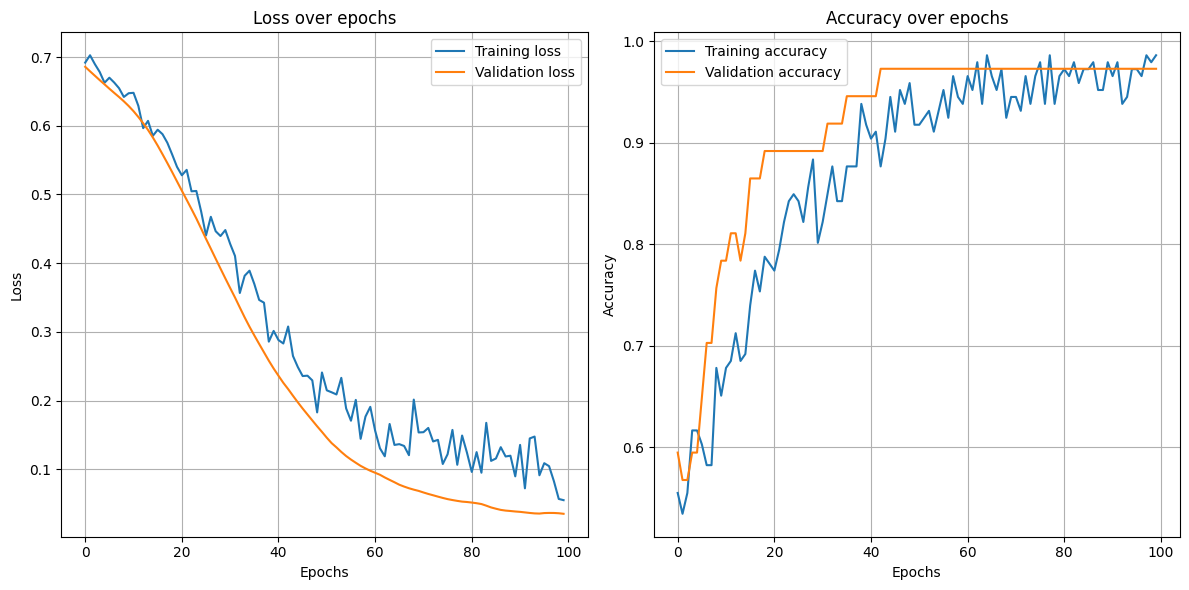

In [21]:
import matplotlib.pyplot as plt
# Plotting the loss and accuracy
plt.figure(figsize=(12, 6))

# Plot training & validation loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Show the plot
plt.tight_layout()
plt.show()

Realizamos ahora la evaluación del modelo de Regresión Logística

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# 1. Definir el modelo
modelo = LogisticRegression(random_state=42)

# 2. Entrenar el modelo
modelo.fit(x_train_scal, y_train)

# 3. Predicciones
y_pred = modelo.predict(x_test_scal)
y_prob = modelo.predict_proba(x_test_scal)[:, 1]  # Probabilidad de la clase 1

# 4. Evaluación

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Matriz de confusión
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Matriz de confusión:
[[16  0]
 [ 0 21]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        21

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37

